In [2]:
!pip install pandas numpy matplotlib seaborn scikit-learn


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


Категориальный признак создан!
   sepal length (cm) sepal_length_cat
0                5.1           medium
1                4.9              low
2                4.7              low
3                4.6              low
4                5.0           medium
5                5.4           medium
6                4.6              low
7                5.0           medium
8                4.4              low
9                4.9              low


Масштабирование выполнено!
До масштабирования (первые 5):
   petal length (cm)
0                1.4
1                1.4
2                1.3
3                1.5
4                1.4

После масштабирования (первые 5):
   petal_length_scaled
0            -1.340227
1            -1.340227
2            -1.397064
3            -1.283389
4            -1.340227


Label Encoding:
low -> 0, medium -> 1, high -> 2
  sepal_length_cat  sepal_length_label
0           medium                   2
1              low                   1
2              low      

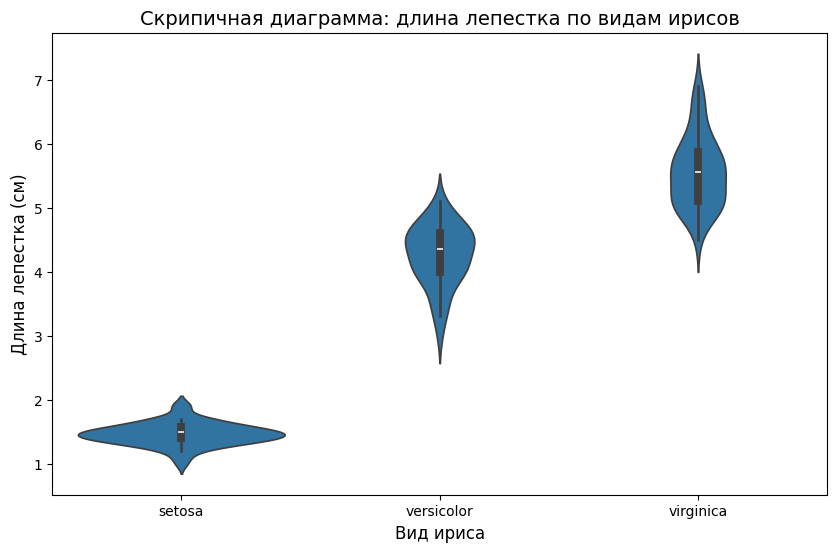


 Все задания выполнены!
Скрипичная диаграмма построена


In [7]:
# Импортируем остальные библиотеки
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Создаём копию данных 
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# 1. СОЗДАЁМ ИСКУССТВЕННЫЙ КАТЕГОРИАЛЬНЫЙ ПРИЗНАК
# Разбиваем sepal length на 3 категории
bins = [0, 5.0, 6.0, 10.0]
labels = ['low', 'medium', 'high']
df['sepal_length_cat'] = pd.cut(df['sepal length (cm)'], bins=bins, labels=labels, right=False)

print("Категориальный признак создан!")
print(df[['sepal length (cm)', 'sepal_length_cat']].head(10))
print("\n")

# 2. МАСШТАБИРОВАНИЕ (для petal length)
scaler = StandardScaler()
df['petal_length_scaled'] = scaler.fit_transform(df[['petal length (cm)']])

print("Масштабирование выполнено!")
print("До масштабирования (первые 5):")
print(df[['petal length (cm)']].head())
print("\nПосле масштабирования (первые 5):")
print(df[['petal_length_scaled']].head())
print("\n")

# 3. LABEL ENCODING
le = LabelEncoder()
df['sepal_length_label'] = le.fit_transform(df['sepal_length_cat'])

print("Label Encoding:")
print("low -> 0, medium -> 1, high -> 2")
print(df[['sepal_length_cat', 'sepal_length_label']].head(10))
print("\n")

# 4. ONE-HOT ENCODING
one_hot = pd.get_dummies(df['sepal_length_cat'], prefix='sepal_cat')
df = pd.concat([df, one_hot], axis=1)

print("One-Hot Encoding (первые 5 строк):")
print(df[['sepal_length_cat', 'sepal_cat_low', 'sepal_cat_medium', 'sepal_cat_high']].head())
print("\n")

# 5. СКРИПИЧНАЯ ДИАГРАММА 
# Добавим целевой признак (виды ирисов) для красивого графика
df['target'] = iris.target
df['species'] = iris.target_names[iris.target]

plt.figure(figsize=(10, 6))
sns.violinplot(x='species', y='petal length (cm)', data=df)
plt.title('Скрипичная диаграмма: длина лепестка по видам ирисов', fontsize=14)
plt.xlabel('Вид ириса', fontsize=12)
plt.ylabel('Длина лепестка (см)', fontsize=12)
plt.show()

print("\n Все задания выполнены!")
print("Скрипичная диаграмма построена")

## Выводы по задаче №3 (вариант 17, датасет Iris)
## Нечаева Мария, ИУ5-64Б
1. Искусственный категориальный признак создан путём бинаризации 'sepal length (cm)' на три категории: low (<5.0), medium (5.0-6.0), high (>6.0). Это необходимо, так как в исходном датасете все признаки числовые.

2. Для масштабирования выбран признак 'petal length (cm)' и метод StandardScaler (стандартизация). Данный метод приводит признак к нулевому среднему и единичной дисперсии, что полезно для алгоритмов, чувствительных к масштабу (например, SVM, линейная регрессия, PCA). Альтернативой мог быть MinMaxScaler для приведения к диапазону [0,1].

3. Преобразование категориального признака выполнено двумя способами:
   - Label Encoding: присвоил категориям числовые метки (low=1, medium=2, high=0). Простой и экономичный метод, но может внести ложный порядок между категориями.
   - One-Hot Encoding: создал три бинарных столбца (sepal_cat_low, sepal_cat_medium, sepal_cat_high). Устраняет проблему ложного порядка, но увеличивает размерность данных.

4. Построенная скрипичная диаграмма для 'petal length (cm)' по видам ирисов показывает, что:
   - Вид setosa имеет наименьшую длину лепестка (около 1.5 см) с узким распределением.
   - Вид versicolor занимает среднее положение (около 4.5 см).
   - Вид virginica имеет наибольшую длину лепестка (около 5.5 см) с более широким распределением.
   - Форма "скрипок" указывает на бимодальность распределения у некоторых видов, что не видно на обычном boxplot.

5. Все преобразования выполнены успешно. Данные готовы для построения моделей машинного обучения, таких как логистическая регрессия или случайный лес.